# Recommender Systems  
## Final Notebook Version — Case Study: Building a Movie Recommender

**Course Topic:** Recommender Systems  
**Case Study:** Building a Movie Recommender using NLP (Content-Based Filtering)

---

## Module 8

### Learning Outcomes
By the end of this notebook, students will be able to:

- Define **recommender systems**
- Distinguish between:
  - **Rule-based recommenders**
  - **Content-based recommenders**
  - **Collaborative filtering**
- Build a **content-based movie recommender**
- Apply:
  - **Text preprocessing**
  - **TF-IDF vectorization**
  - **Cosine similarity**
- Evaluate recommendation quality qualitatively

---

## Case Study Overview
We will build a simple **movie recommender system** using:
- movie **tagline**
- movie **overview**
- **text preprocessing**
- **TF-IDF**
- **cosine similarity**

This is a **content-based recommender**, where movies are recommended based on similarity in textual descriptions.


# 1. Introduction to Recommender Systems

A **recommender system** is a system that suggests items to users based on available information.

## Common Examples
- Amazon recommends products
- Netflix recommends movies and shows
- YouTube recommends videos
- Spotify recommends music

---

## Main Types of Recommender Systems

### 1) Rule-Based Recommenders
Simple recommendations based on:
- popularity
- global ratings
- trending items

### 2) Content-Based Recommenders
Recommend items similar to a target item using metadata such as:
- description
- genre
- cast
- director
- keywords

### 3) Collaborative Filtering
Recommend items based on:
- user-item interactions
- ratings history
- similar users or similar items

---

## Today’s Focus
We will build a **Content-Based Movie Recommender** using **NLP**.


# 2. System Pipeline

## Recommendation Pipeline

1. Load movie dataset  
2. Keep relevant columns  
3. Build a combined text field (`description`)  
4. Normalize the text  
5. Convert text into TF-IDF vectors  
6. Compute cosine similarity between all movies  
7. Retrieve top-N similar movies  
8. Package everything into a reusable recommender function  

---

## Why This Works
If two movies have similar:
- story descriptions
- tagline language
- franchise-related words
- genre-like terms

...then their TF-IDF vectors will be similar, which leads to a high cosine similarity score.


# 3. Optional Classroom Diagram

```text
Movie Data
   │
   ▼
Select Relevant Columns
   │
   ▼
Create Combined Description
   │
   ▼
Text Preprocessing
   │
   ▼
TF-IDF Vectorization
   │
   ▼
Cosine Similarity Matrix
   │
   ▼
Top-N Similar Movies
   │
   ▼
Movie Recommendations
```


In [8]:
# 4. Import Required Libraries

import pandas as pd
import numpy as np
import re
import nltk
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity


In [9]:
# 5. Download NLTK Resources (Run once if needed)

nltk.download('punkt')
nltk.download('stopwords')


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Hitham\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Hitham\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

# 4. Load the Dataset

We use the **TMDB 5000 Movies Dataset** (as referenced in the textbook case study).

### Expected filename
- `tmdb_5000_movies.csv.gz` (preferred)
or
- `tmdb_5000_movies.csv`

> If the file is not in your notebook folder, place it in the same directory as this notebook.


In [10]:
# 6. Load Dataset

try:
    df = pd.read_csv('tmdb_5000_movies.csv.gz', compression='gzip')
    print("Loaded compressed dataset successfully.")
except Exception:
    df = pd.read_csv('tmdb_5000_movies.csv')
    print("Loaded regular CSV dataset successfully.")

print("Original dataset shape:", df.shape)
df.head()


Loaded regular CSV dataset successfully.
Original dataset shape: (4803, 20)


,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,production_companies,production_countries,release_date,revenue,runtime,spoken_languages,status,tagline,title,vote_average,vote_count
0,237000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.avatarmovie.com/,19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2009-12-10,2787965087,162.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Released,Enter the World of Pandora.,Avatar,7.2,11800
1,300000000,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...",http://disney.go.com/disneypictures/pirates/,285,"[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...",en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139.082615,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2007-05-19,961000000,169.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"At the end of the world, the adventure begins.",Pirates of the Caribbean: At World's End,6.9,4500
2,245000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.sonypictures.com/movies/spectre/,206647,"[{""id"": 470, ""name"": ""spy""}, {""id"": 818, ""name...",en,Spectre,A cryptic message from Bond’s past sends him o...,107.376788,"[{""name"": ""Columbia Pictures"", ""id"": 5}, {""nam...","[{""iso_3166_1"": ""GB"", ""name"": ""United Kingdom""...",2015-10-26,880674609,148.0,"[{""iso_639_1"": ""fr"", ""name"": ""Fran\u00e7ais""},...",Released,A Plan No One Escapes,Spectre,6.3,4466
3,250000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 80, ""nam...",http://www.thedarkknightrises.com/,49026,"[{""id"": 849, ""name"": ""dc comics""}, {""id"": 853,...",en,The Dark Knight Rises,Following the death of District Attorney Harve...,112.312950,"[{""name"": ""Legendary Pictures"", ""id"": 923}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2012-07-16,1084939099,165.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,The Legend Ends,The Dark Knight Rises,7.6,9106
4,260000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://movies.disney.com/john-carter,49529,"[{""id"": 818, ""name"": ""based on novel""}, {""id"":...",en,John Carter,"John Carter is a war-weary, former military ca...",43.926995,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}]","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2012-03-07,284139100,132.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"Lost in our world, found in another.",John Carter,6.1,2124


In [11]:
# 7. Inspect Dataset Columns

print("Columns:")
print(df.columns.tolist())


Columns:
['budget', 'genres', 'homepage', 'id', 'keywords', 'original_language', 'original_title', 'overview', 'popularity', 'production_companies', 'production_countries', 'release_date', 'revenue', 'runtime', 'spoken_languages', 'status', 'tagline', 'title', 'vote_average', 'vote_count']


# 5. Select Relevant Features

For a simple **content-based** recommender, we only keep:

- `title`
- `tagline`
- `overview`
- `genres`
- `popularity`

We then create:

- `description = tagline + overview`


In [12]:
# 8. Keep only relevant columns

df = df[['title', 'tagline', 'overview', 'genres', 'popularity']].copy()

# Fill missing taglines
df['tagline'] = df['tagline'].fillna('')

# Drop rows with missing title or overview
df = df.dropna(subset=['title', 'overview'])

# Build combined text description
df['description'] = df['tagline'].astype(str) + ' ' + df['overview'].astype(str)

print("Cleaned dataset shape:", df.shape)
df.head()


Cleaned dataset shape: (4800, 6)


,title,tagline,overview,genres,popularity,description
0,Avatar,Enter the World of Pandora.,"In the 22nd century, a paraplegic Marine is di...","[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",150.437577,Enter the World of Pandora. In the 22nd centur...
1,Pirates of the Caribbean: At World's End,"At the end of the world, the adventure begins.","Captain Barbossa, long believed to be dead, ha...","[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...",139.082615,"At the end of the world, the adventure begins...."
2,Spectre,A Plan No One Escapes,A cryptic message from Bond’s past sends him o...,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",107.376788,A Plan No One Escapes A cryptic message from B...
3,The Dark Knight Rises,The Legend Ends,Following the death of District Attorney Harve...,"[{""id"": 28, ""name"": ""Action""}, {""id"": 80, ""nam...",112.312950,The Legend Ends Following the death of Distric...
4,John Carter,"Lost in our world, found in another.","John Carter is a war-weary, former military ca...","[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",43.926995,"Lost in our world, found in another. John Cart..."


# 6. Text Preprocessing

Before vectorization, we normalize the text.

## Preprocessing Steps
- remove special characters
- lowercase
- tokenize
- remove stopwords
- join tokens back into text

This reduces noise and improves similarity quality.


In [13]:
# 9. Text Preprocessing Function

stop_words = set(nltk.corpus.stopwords.words('english'))

def normalize_document(doc):
    # Remove special characters, keep letters/numbers/spaces
    doc = re.sub(r'[^a-zA-Z0-9\s]', ' ', str(doc))

    # Lowercase and strip
    doc = doc.lower().strip()

    # Tokenize
    tokens = nltk.word_tokenize(doc)

    # Remove stopwords
    filtered_tokens = [token for token in tokens if token not in stop_words]

    # Re-join
    return ' '.join(filtered_tokens)


In [14]:
# 10. Apply Normalization to Entire Corpus

normalize_corpus = np.vectorize(normalize_document)
norm_corpus = normalize_corpus(df['description'].values)

print("Number of normalized documents:", len(norm_corpus))
print("\nSample original description:\n")
print(df['description'].iloc[0][:500])

print("\nSample normalized description:\n")
print(norm_corpus[0][:500])


Number of normalized documents: 4800

Sample original description:

Enter the World of Pandora. In the 22nd century, a paraplegic Marine is dispatched to the moon Pandora on a unique mission, but becomes torn between following orders and protecting an alien civilization.

Sample normalized description:

enter world pandora 22nd century paraplegic marine dispatched moon pandora unique mission becomes torn following orders protecting alien civilization


# 7. Feature Engineering with TF-IDF

We now convert the normalized descriptions into numeric vectors using **TF-IDF**.

## Why TF-IDF?
TF-IDF emphasizes words that are:
- frequent in a specific movie description
- but not common across all movie descriptions

## Parameters Used
- `ngram_range=(1,2)` → use unigrams and bigrams
- `min_df=2` → ignore terms that appear in only 1 document


In [15]:
# 11. Build TF-IDF Matrix

tfidf = TfidfVectorizer(ngram_range=(1, 2), min_df=2)
tfidf_matrix = tfidf.fit_transform(norm_corpus)

print("TF-IDF matrix shape:", tfidf_matrix.shape)


TF-IDF matrix shape: (4800, 20796)


# 8. Compute Cosine Similarity

We compute **cosine similarity** between every pair of movies.

## Interpretation
- **1.0** → highly similar
- **0.0** → not similar

This produces a **movie-to-movie similarity matrix**.


In [16]:
# 12. Compute Cosine Similarity Matrix

doc_sim = cosine_similarity(tfidf_matrix)
doc_sim_df = pd.DataFrame(doc_sim)

print("Similarity matrix shape:", doc_sim_df.shape)
doc_sim_df.iloc[:5, :5]


Similarity matrix shape: (4800, 4800)


,0,1,2,3,4
0,1.000000,0.009070,0.000000,0.015911,0.024535
1,0.009070,1.000000,0.011727,0.000000,0.040078
2,0.000000,0.011727,1.000000,0.000000,0.000000
3,0.015911,0.000000,0.000000,1.000000,0.008087
4,0.024535,0.040078,0.000000,0.008087,1.000000


# 9. Visualize a Small Similarity Heatmap (Optional)

To avoid plotting a huge matrix, we visualize only the first 20 movies.


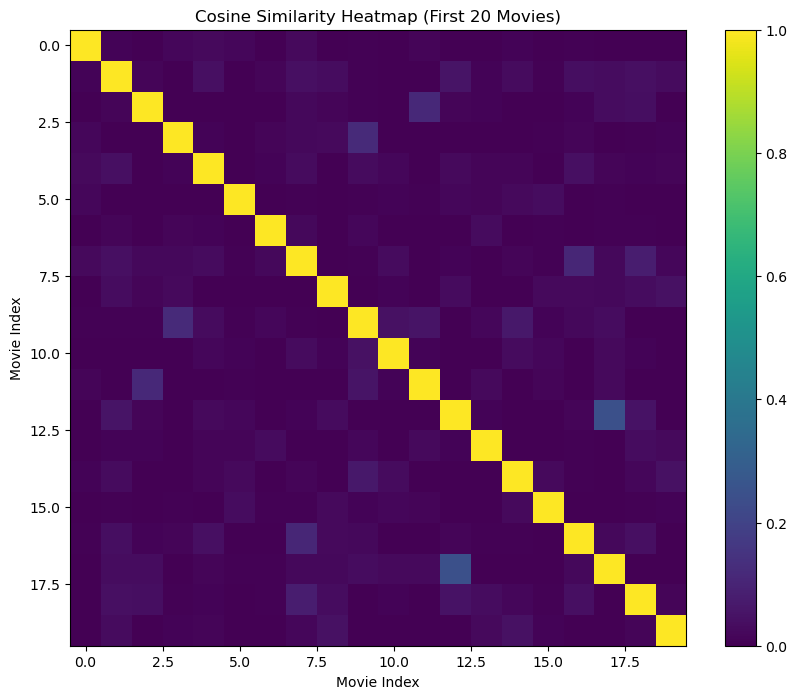

In [17]:
# 13. Heatmap for First 20 Movies (Optional Visualization)

subset_size = 20
subset_sim = doc_sim_df.iloc[:subset_size, :subset_size]

plt.figure(figsize=(10, 8))
plt.imshow(subset_sim, interpolation='nearest')
plt.colorbar()
plt.title("Cosine Similarity Heatmap (First 20 Movies)")
plt.xlabel("Movie Index")
plt.ylabel("Movie Index")
plt.show()


# 10. Create Movie Index Mapping

We need a fast way to map:

- **movie title → row index**

This allows us to retrieve the similarity vector for any selected movie.


In [18]:
# 14. Create Movie Title List

movies_list = df['title'].values

print("Total movies available:", len(movies_list))
print("Sample titles:")
print(movies_list[:10])


Total movies available: 4800
Sample titles:
['Avatar' "Pirates of the Caribbean: At World's End" 'Spectre'
 'The Dark Knight Rises' 'John Carter' 'Spider-Man 3' 'Tangled'
 'Avengers: Age of Ultron' 'Harry Potter and the Half-Blood Prince'
 'Batman v Superman: Dawn of Justice']


# 11. Manual Example: Recommend Similar Movies to "Minions"

We now walk through the recommendation process step by step.

## Steps
1. Find movie index
2. Get similarity scores
3. Sort descending
4. Ignore the movie itself
5. Return top-N similar titles


In [19]:
# 15. Example Movie

sample_movie = 'Minions'

if sample_movie in movies_list:
    movie_idx = np.where(movies_list == sample_movie)[0][0]
    print(f"Index of '{sample_movie}':", movie_idx)
else:
    print(f"Movie '{sample_movie}' not found in dataset.")


Index of 'Minions': 546


In [20]:
# 16. Get Similarity Scores for Sample Movie

if sample_movie in movies_list:
    movie_similarities = doc_sim_df.iloc[movie_idx].values
    print("First 10 similarity scores:")
    print(movie_similarities[:10])


First 10 similarity scores:
[0.00875589 0.01008932 0.         0.         0.01469255 0.02930371
 0.022198   0.         0.         0.03325653]


In [21]:
# 17. Get Top 5 Similar Movie Indices

if sample_movie in movies_list:
    similar_movie_idxs = np.argsort(-movie_similarities)[1:6]  # skip itself
    print("Top 5 similar movie indices:", similar_movie_idxs)


Top 5 similar movie indices: [ 506  614  813  221 3943]


In [22]:
# 18. Convert Indices to Titles

if sample_movie in movies_list:
    similar_movies = movies_list[similar_movie_idxs]
    print(f"Top 5 movies similar to '{sample_movie}':")
    print(similar_movies)


Top 5 movies similar to 'Minions':
['Despicable Me 2' 'Despicable Me' 'Superman' 'Stuart Little 2' 'Freeway']


# 12. Build the Final Recommender Function

We now package the full workflow into a reusable function.

## Function Features
- checks whether the movie exists
- returns top-N recommendations
- can optionally return similarity scores


In [23]:
# 19. Final Recommender Function

def movie_recommender(movie_title, movies=movies_list, doc_sims=doc_sim_df, top_n=5):
    '''
    Recommend top_n movies similar to the given movie_title.
    Returns a NumPy array of movie titles.
    '''
    if movie_title not in movies:
        return np.array([f"Movie '{movie_title}' not found in dataset."])

    # Find movie index
    movie_idx = np.where(movies == movie_title)[0][0]

    # Get similarity scores
    movie_similarities = doc_sims.iloc[movie_idx].values

    # Sort in descending order and skip the movie itself
    similar_movie_idxs = np.argsort(-movie_similarities)[1:top_n+1]

    # Return movie titles
    return movies[similar_movie_idxs]


In [24]:
# 20. Recommender with Scores (Useful for Teaching / Analysis)

def movie_recommender_with_scores(movie_title, movies=movies_list, doc_sims=doc_sim_df, top_n=5):
    '''
    Recommend top_n movies and return similarity scores in a DataFrame.
    '''
    if movie_title not in movies:
        return pd.DataFrame({
            'Movie': [f"Movie '{movie_title}' not found in dataset."],
            'Similarity': [None]
        })

    movie_idx = np.where(movies == movie_title)[0][0]
    movie_similarities = doc_sims.iloc[movie_idx].values

    similar_movie_idxs = np.argsort(-movie_similarities)[1:top_n+1]

    results = pd.DataFrame({
        'Movie': movies[similar_movie_idxs],
        'Similarity': movie_similarities[similar_movie_idxs]
    })

    return results


In [25]:
# 21. Quick Test

movie_recommender('Minions')


array(['Despicable Me 2', 'Despicable Me', 'Superman', 'Stuart Little 2',
       'Freeway'], dtype=object)

In [26]:
# 22. Quick Test with Scores

movie_recommender_with_scores('Interstellar')


,Movie,Similarity
0,Gattaca,0.136823
1,Space Cowboys,0.129740
2,Space Pirate Captain Harlock,0.125930
3,Final Destination 2,0.105826
4,Starship Troopers,0.101303


# 13. Test on Popular Movies

We can inspect recommendations for several well-known movies to evaluate whether the results look reasonable.


In [27]:
# 23. View Most Popular Movies

pop_movies = df.sort_values(by='popularity', ascending=False)
pop_movies[['title', 'popularity']].head(15)


,title,popularity
546,Minions,875.581305
95,Interstellar,724.247784
788,Deadpool,514.569956
94,Guardians of the Galaxy,481.098624
127,Mad Max: Fury Road,434.278564
28,Jurassic World,418.708552
199,Pirates of the Caribbean: The Curse of the Bla...,271.972889
82,Dawn of the Planet of the Apes,243.791743
200,The Hunger Games: Mockingjay - Part 1,206.227151
88,Big Hero 6,203.734590


In [28]:
# 24. Selected Movies for Demo

popular_movies = [
    'Minions',
    'Interstellar',
    'Deadpool',
    'Jurassic World',
    'Pirates of the Caribbean: The Curse of the Black Pearl',
    'Captain America: Civil War',
    'The Dark Knight',
    'The Martian',
    'The Godfather',
    'Iron Man'
]

popular_movies


['Minions',
 'Interstellar',
 'Deadpool',
 'Jurassic World',
 'Pirates of the Caribbean: The Curse of the Black Pearl',
 'Captain America: Civil War',
 'The Dark Knight',
 'The Martian',
 'The Godfather',
 'Iron Man']

In [29]:
# 25. Generate Recommendations for Selected Movies

for movie in popular_movies:
    print("=" * 90)
    print("Movie:", movie)
    print("Top 5 Recommended Movies:")
    print(movie_recommender(movie))
    print()


Movie: Minions
Top 5 Recommended Movies:
['Despicable Me 2' 'Despicable Me' 'Superman' 'Stuart Little 2' 'Freeway']

Movie: Interstellar
Top 5 Recommended Movies:
['Gattaca' 'Space Cowboys' 'Space Pirate Captain Harlock'
 'Final Destination 2' 'Starship Troopers']

Movie: Deadpool
Top 5 Recommended Movies:
['Silent Trigger' 'Underworld: Evolution' 'Mars Attacks!' 'Bronson'
 'Shaft']

Movie: Jurassic World
Top 5 Recommended Movies:
['The Lost World: Jurassic Park' 'Jurassic Park'
 "National Lampoon's Vacation" 'The Nut Job' 'Vacation']

Movie: Pirates of the Caribbean: The Curse of the Black Pearl
Top 5 Recommended Movies:
["Pirates of the Caribbean: Dead Man's Chest" 'The Pirate'
 'Pirates of the Caribbean: On Stranger Tides' 'The New World'
 'The Pirates! In an Adventure with Scientists!']

Movie: Captain America: Civil War
Top 5 Recommended Movies:
['Captain America: The Winter Soldier' 'Avengers: Age of Ultron'
 'This Means War' 'Iron Man 2' 'Escape from Tomorrow']

Movie: The Dark 

# 14. Classroom Analysis

## Discussion Prompt
When you inspect the recommendations, ask:

- Are the results from the same franchise?
- Are the story themes similar?
- Are the recommended movies semantically reasonable?
- Which recommendations look correct?
- Which recommendations look surprising or weak?

This is a great point to discuss:
- **precision**
- **qualitative evaluation**
- **limitations of keyword-based similarity**


# 15. Strengths of This Content-Based Approach

## Advantages
- Easy to understand
- Easy to implement
- No user ratings required
- Works for new items (cold-start for items)
- Good baseline for educational projects
- Highly interpretable


# 16. Limitations of This Approach

## Limitations
1. Uses only text metadata
2. Ignores user preferences and behavior
3. TF-IDF captures lexical overlap, not deep semantics
4. Similar meaning can be missed if different words are used
5. Some recommendations may be noisy or unintuitive

## Example
Two movies may be very similar in theme, but if their descriptions use different wording, the system may fail to match them well.


# 17. Possible Improvements

## Better Metadata
You can improve this recommender by adding:
- genres
- keywords
- cast
- director
- production companies

## Better Models
Instead of TF-IDF, try:
- Word2Vec
- GloVe
- Doc2Vec
- Sentence Transformers
- BERT embeddings

## Hybrid Systems
Combine:
- content-based filtering
- collaborative filtering
- popularity signals
- user ratings


# 18. Student Practice Activity

## Task
Choose **one movie** and:

1. Run the recommender
2. Inspect the top 5 recommendations
3. Decide whether the results are reasonable
4. Explain **why** those movies were recommended

### Extension
Change TF-IDF parameters and compare results:
- `ngram_range=(1,1)`
- `ngram_range=(1,2)`
- `min_df=1`
- `min_df=3`


In [30]:
# 26. Student Practice Cell

student_movie = 'The Dark Knight'
print("Recommendations for:", student_movie)
movie_recommender_with_scores(student_movie)


Recommendations for: The Dark Knight


,Movie,Similarity
0,The Dark Knight Rises,0.311740
1,Batman Forever,0.237240
2,Batman Returns,0.210346
3,"Batman: The Dark Knight Returns, Part 2",0.175366
4,Batman,0.165563


# 19. Homework / Lab Exercise

## Lab Questions
1. Why is this recommender considered **content-based**?
2. Why do we use **TF-IDF** instead of raw term frequency?
3. Why do we remove **stopwords**?
4. Why do we skip the first result after sorting similarities?
5. What are the limitations of using only text descriptions?
6. How would collaborative filtering differ from this approach?

## Coding Task
Modify the recommender so that it uses:
- `genres`
- `tagline`
- `overview`

Then compare whether recommendations improve.


# 20. Summary

In this lecture, we built a **Content-Based Movie Recommender** using:

- **Text preprocessing**
- **TF-IDF feature engineering**
- **Cosine similarity**
- **Top-N ranking**

## Final Takeaway
A simple **TF-IDF + Cosine Similarity** pipeline can produce useful movie recommendations and is an excellent way to teach the fundamentals of recommender systems.

---

## End of Notebook
